# Basic Denoising Process

This notebook focuses on denoising process using transformer, not including training.

There are two parts in this code:
1. First half part is from the blog [Training a Latent Diffusion Model From Scratch](https://medium.com/@geronimo7/training-a-latent-diffusion-model-from-scratch-897c7b77ece9)'s author, Geronimo, and the [repo].(https://github.com/geronimi73/Hana/blob/main/blogpost/basics_denoising.ipynb)
2. Second half code is generated by gemini (with some minor correction).

NOTE (what I learned):
* param `attn_implementation="eager` is important in **text_encoder**. Without it, the text_encoder is an all-Nan tensor.
* `generator=torch.Generator(device=device).manual_seed(42)` is important while generating a latent.
* Everytime when running denoising process, need to generate a new latent.

# 1. Denoising Code By Geronimo

### Text Encoder

In [1]:
def encode_prompt(prompt, tokenizer, text_encoder, max_length=50, add_special_tokens=False, **kwargs):
    # lower case prompt! took a long time to find that this is necessary: https://github.com/huggingface/diffusers/blob/e8aacda762e311505ba05ae340af23b149e37af3/src/diffusers/pipelines/sana/pipeline_sana.py#L433

    tokenizer.padding_side = "right"
    if isinstance(prompt, list):
        prompt = [p.lower().strip() for p in prompt]
    elif isinstance(prompt, str):
        print(prompt)
        prompt = prompt.lower().strip()
    else:
        raise Exception(f"Unknown prompt type {type(prompt)}")

    prompt_tok = tokenizer(
        prompt,
        return_tensors="pt",
        return_attention_mask=True,
        # padding="max_length",
        truncation=True,
        max_length=max_length,
        add_special_tokens=add_special_tokens
    ).to(text_encoder.device)
    
    with torch.no_grad():
        prompt_encoded=text_encoder(**prompt_tok)

    return prompt_encoded.last_hidden_state, prompt_tok.attention_mask


def latent_to_PIL(latent, vae):
    with torch.no_grad():
        image_out = vae.decode(latent).sample.to("cpu")
    
    if image_out.size(0) == 1:
        # Single image processing
        image_out = torch.clamp_(image_out[0,:], -1, 1)
        image_out = image_out * 0.5 + 0.5
        return T.ToPILImage()(image_out.float())
    else:
        images = []
        for img in image_out:
            img = torch.clamp_(img, -1, 1)
            img = img * 0.5 + 0.5
            images.append(T.ToPILImage()(img.float()))
        return images

In [2]:
import torch
import torchvision.transforms as T
from transformers import Gemma2Model, GemmaTokenizerFast

# dtype = torch.bfloat16
dtype = torch.float32
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
# device="cpu"

/home/colligo/diffusion/transformer/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model_repo = "Efficient-Large-Model/Sana_600M_1024px_diffusers"

tokenizer = GemmaTokenizerFast.from_pretrained(
    model_repo, 
    subfolder="tokenizer", 
    torch_dtype=dtype
)

text_encoder = Gemma2Model.from_pretrained(
    model_repo, 
    subfolder="text_encoder", 
    torch_dtype=dtype
).to(device)

Loading checkpoint shards: 100%|██████████████████| 2/2 [00:03<00:00,  1.62s/it]


In [4]:
prompt = "A beautiful mountain landscape"

# lower case prompt. see https://github.com/huggingface/diffusers/blob/e8aacda762e311505ba05ae340af23b149e37af3/src/diffusers/pipelines/sana/pipeline_sana.py#L433
prompt = prompt.lower().strip()

# text string to token ids
prompt_tok = tokenizer(
    prompt, 
    return_tensors="pt", 
    return_attention_mask=True, 
    # padding="max_length", 
    truncation=True, 
    max_length=300, 
    add_special_tokens=True
).to(text_encoder.device)

# encode token ids
with torch.no_grad():
    prompt_encoded=text_encoder(**prompt_tok)
    
print("prompt_encoded['input_ids']:\n", prompt_tok["input_ids"])
print("prompt_encoded['attention_mask']:\n", prompt_tok["attention_mask"])
print("prompt_encoded.last_hidden_state.shape:\n", prompt_encoded.last_hidden_state.shape)


prompt_encoded['input_ids']:
 tensor([[     2, 235250,   4964,   8180,  15487]], device='cuda:0')
prompt_encoded['attention_mask']:
 tensor([[1, 1, 1, 1, 1]], device='cuda:0')
prompt_encoded.last_hidden_state.shape:
 torch.Size([1, 5, 2304])


In [5]:
from diffusers import AutoencoderDC, SanaTransformer2DModel

model_repo = "Efficient-Large-Model/Sana_600M_1024px_diffusers"

transformer = SanaTransformer2DModel.from_pretrained(
    model_repo,
    subfolder="transformer", 
    torch_dtype=dtype
).to(device)

vae = AutoencoderDC.from_pretrained(
    model_repo, 
    subfolder="vae", 
    torch_dtype=dtype
).to(device)

### Generating Random Noise

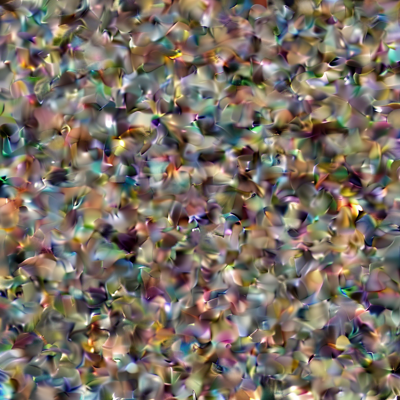

In [6]:
# batch size 1, 32 channels, height/width of 16 (=1024/32)
latent = torch.randn(
    [1, 32, 32, 32],
    dtype=dtype,
    generator=torch.manual_seed(42)
).to(device)

# fixed constant scaling_factor applied before invoking AutoEncoder
latent_to_PIL(latent / vae.config["scaling_factor"], vae).resize((400, 400))

### Denoising process

In [18]:
prompt = "A beautiful mountain landscape, photorealistic"

# Encode the prompt
# prompt_encoded, prompt_atnmask = encode_prompt(prompt, tokenizer, text_encoder)
prompt_encoded, prompt_atnmask = encode_prompt(prompt, tokenizer, text_encoder, add_special_tokens=True)

# prompt_encoded = prompt_encoded.last_hidden_state
# if hasattr(transformer, "caption_projection"):
    # prompt_encoded = transformer.caption_projection(prompt_encoded)

# Number of steps to take from noise to image
num_steps = 20

timesteps = torch.linspace(1000, 0, num_steps + 1).to(device)


# Noise level. 1.0 -> 0.0 in equally sized steps
sigmas = timesteps / 1000


dt = 1.0 / num_steps

for t, sigma_prev, sigma_next, steps_left in zip(
    timesteps, 
    sigmas[:-1], 
    sigmas[1:], 
    range(num_steps, 0, -1)
):

    
    # DiT predicts noise
    with torch.no_grad():
        noise_pred = transformer(
            latent, 
            timestep=t[None].to(vae.dtype).to(vae.device), 
            encoder_hidden_states=prompt_encoded, 
            encoder_attention_mask=prompt_atnmask, 
            return_dict=False
        )[0]

    latent = latent + (sigma_next - sigma_prev) * noise_pred 
    

latent_to_PIL(latent / vae.config["scaling_factor"], vae).resize((512, 512))

TypeError: encode_prompt() got an unexpected keyword argument 'add_special_tokens'

In [10]:
from diffusers import FlowMatchEulerDiscreteScheduler

# 3. Load the Scheduler (Flow Matching)
scheduler = FlowMatchEulerDiscreteScheduler.from_pretrained(
    "Efficient-Large-Model/Sana_600M_1024px_diffusers", 
    subfolder="scheduler"
)

In [11]:
from diffusers import SanaPipeline

# 5. Assemble the Pipeline manually
pipe = SanaPipeline(
    transformer=transformer,
    vae=vae,
    text_encoder=text_encoder,
    tokenizer=tokenizer,
    scheduler=scheduler
)

100%|███████████████████████████████████████████| 20/20 [00:02<00:00,  9.35it/s]


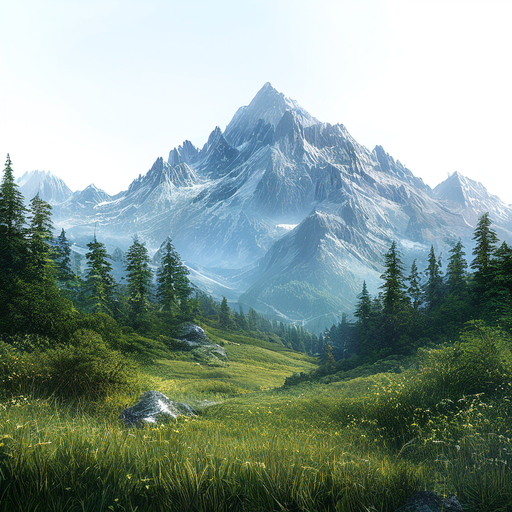

In [12]:
pipe.to(device) # Use MPS for your M3

image = pipe(prompt="A beautiful mountain landscape, photorealistic").images[0]
# image.show()

from PIL import Image
resized_image = image.resize((512, 512), Image.LANCZOS)

# 3. Show the result
resized_image.show()

# 2. Denoising Code Generated by Gemini

This second half part is generated by Gemini.

NOTE:
1. param `attn_implementation="eager` is important in **text_encoder**. Without it, the text_encoder is an all-Nan tensor.
2. `generator=torch.Generator(device=device).manual_seed(42)` is important while generating a latent.
3. Everytime when running denoising process, need to generate a new latent.
4. If device = "cpu", point 1 param is not requied.

In [18]:
!pip install huggingface_hub

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 7.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 100.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [huggingface_hub]32m10/11 [huggingface_hub]


In [ ]:
from huggingface_hub import login
login(token=<huggingface-key>) # which is usually ""hf_xxxxxx.....""

Loading models...


Loading checkpoint shards: 100%|██████████████████| 2/2 [00:00<00:00, 56.82it/s]


device: cuda
Denoising...


100%|███████████████████████████████████████████| 50/50 [00:02<00:00, 24.25it/s]


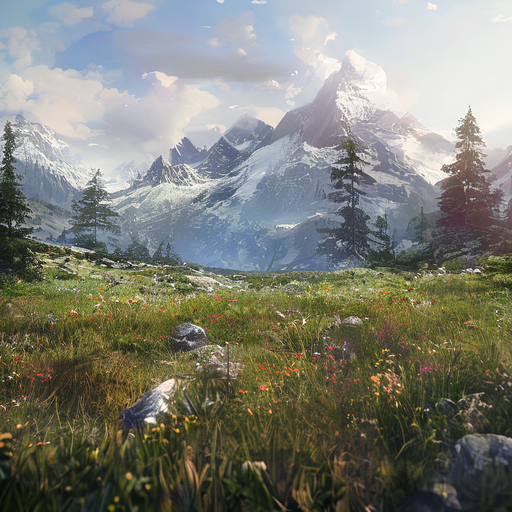

In [4]:
import torch
from tqdm.auto import tqdm
from PIL import Image
from torchvision import transforms as T
from transformers import Gemma2Model, AutoTokenizer, GemmaTokenizerFast
from diffusers import AutoencoderDC, SanaTransformer2DModel, FlowMatchEulerDiscreteScheduler


# 1. SETUP CONFIG
# device = "mps" if torch.backends.mps.is_available() else "cpu"
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

# dtype = torch.float32 # Use float32 to avoid precision issues during manual loop
dtype = torch.bfloat16

model_repo = "Efficient-Large-Model/Sana_600M_1024px_diffusers"

# 2. LOAD MODELS
print("Loading models...")
# tokenizer = AutoTokenizer.from_pretrained("google/gemma-2-2b-it")
# text_encoder = Gemma2Model.from_pretrained("google/gemma-2-2b-it", torch_dtype=dtype, force_download=True,
    # resume_download=False, attn_implementation="eager").to(device)

tokenizer = GemmaTokenizerFast.from_pretrained(
    model_repo, 
    subfolder="tokenizer", 
    torch_dtype=dtype
)

# NOTE attn_implementation="eager" is importnat. Otherwise after text_encoder with device="cuda" gave all nan tensor
text_encoder = Gemma2Model.from_pretrained(
    model_repo, 
    subfolder="text_encoder", 
    torch_dtype=dtype,
    attn_implementation="eager"
).to(device)

# Load Transformer & VAE from the specific Sana repo
transformer = SanaTransformer2DModel.from_pretrained(model_repo, subfolder="transformer", torch_dtype=dtype).to(device)
vae = AutoencoderDC.from_pretrained(model_repo, subfolder="vae", torch_dtype=dtype).to(device)

# 3. HELPER FUNCTIONS
def encode_prompt(prompt, tokenizer, text_encoder):
    prompt = prompt.lower().strip()
    inputs = tokenizer(prompt, return_tensors="pt", padding="max_length", 
                       max_length=300, truncation=True, add_special_tokens=True).to(device)

    with torch.no_grad():
        outputs = text_encoder(**inputs)    
        # 1. Start with raw Gemma output (Shape: [1, 300, 2304])
        prompt_embeds = outputs.last_hidden_state
            
    return prompt_embeds, inputs.attention_mask
    

def latent_to_pil(latent, vae):
    # Scale back before decoding
    latent = latent / vae.config.scaling_factor
    with torch.no_grad():
        image = vae.decode(latent).sample
    
    image = (image / 2 + 0.5).clamp(0, 1)
    image = image.cpu().permute(0, 2, 3, 1).float().numpy()[0]
    return Image.fromarray((image * 255).astype("uint8"))


# 4. GENERATION PARAMETERS
prompt = "A beautiful mountain landscape, photorealistic"

num_steps = 50

# Initialize Latent (1024 / 32 = 32)
# NOTE the initial latent need to be initialized as below; otherwise denoising failed
# also, every time running a denoising process, need to generate a new random latent
latent = torch.randn([1, 32, 32, 32], dtype=dtype, device=device, generator=torch.Generator(device=device).manual_seed(42))

print(f"device: {device}")

# Encode Text
prompt_embeds, attention_mask = encode_prompt(prompt, tokenizer, text_encoder)

# Setup Flow Matching Timesteps (1.0 -> 0.0)
timesteps = torch.linspace(1.0, 0.0, num_steps + 1).to(device)

# 5. THE MANUAL FLOW MATCHING LOOP
print("Denoising...")
for i in tqdm(range(num_steps)):
    t_curr = timesteps[i]
    t_next = timesteps[i+1]
    dt = t_next - t_curr # Usually -0.05
    
    # Scale t to [0, 1000] for the model's embedding layer
    t_input = (t_curr * 1000).expand(latent.shape[0]).to(device)

    with torch.no_grad():
        # Classifier-Free Guidance (Optional but recommended for quality)
        # For simplicity, this version is base-only. 
        # Add a null_prompt embedding here for better quality.
        
        v = transformer(
            latent, 
            timestep=t_input, 
            encoder_hidden_states=prompt_embeds,
            encoder_attention_mask=attention_mask,
            return_dict=False
        )[0]

        # v/latent are  embedding tenors with dim=(1,32,32,32), v is pred_noise latent.
        # if i == 0:
        #     print(type(v), v.shape)
        #     print(v)
    
    # Euler Update: x_next = x_curr + velocity * dt
    latent = latent + v * dt

# 6. DECODE & SHOW
image = latent_to_pil(latent, vae)

from PIL import Image
resized_image = image.resize((512, 512), Image.LANCZOS)
resized_image.show()

## Classifier Free Guidance (CFG) with Sana

Guidance improves the quality of your images.

CFG works by jointly training a single model to handle both prompted and unprompted generation — during training, the conditioning information (text prompts) is randomly dropped with some probability like 10% or 20%, forcing the model to learn unconditional generation alongside conditional generation.

### without CFG

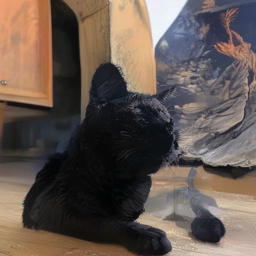

In [6]:
from utils import generate

generate(
    "A beautiful black cat", 
    transformer, tokenizer, text_encoder, vae,
    seed=32, 
    num_steps=20, 
    latent_dim = [1, 32, 32, 32], 
    guidance_scale=1,
    add_special_tokens = True,
).resize((256, 256))

### with CFG


  0%|                                                     | 0/6 [00:00<?, ?it/s]

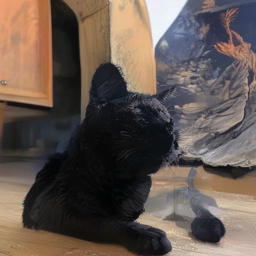


 17%|███████▌                                     | 1/6 [00:01<00:05,  1.06s/it]

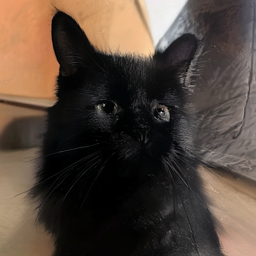


 33%|███████████████                              | 2/6 [00:02<00:04,  1.05s/it]

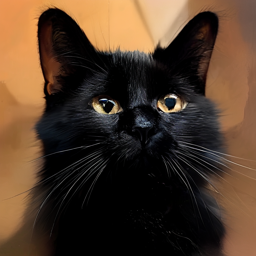


 50%|██████████████████████▌                      | 3/6 [00:03<00:03,  1.04s/it]

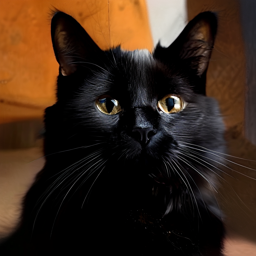


 67%|██████████████████████████████               | 4/6 [00:04<00:02,  1.04s/it]

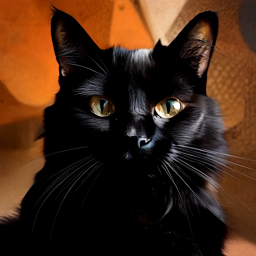


 83%|█████████████████████████████████████▌       | 5/6 [00:05<00:01,  1.05s/it]

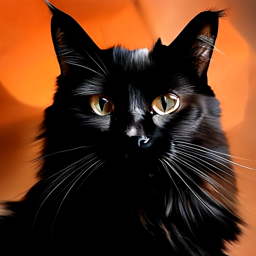


100%|█████████████████████████████████████████████| 6/6 [00:06<00:00,  1.05s/it]


In [10]:
for guidance_scale in tqdm([1, 2, 4, 6, 8, 10]):
    gen_img = generate(
        "A beautiful black cat", 
        transformer, tokenizer, text_encoder, vae,
        seed=32, 
        num_steps=20, 
        latent_dim = [1, 32, 32, 32], 
        guidance_scale=guidance_scale,
        add_special_tokens = True,
    ).resize((256, 256))
    gen_img.show()
